In [3]:
# 새 데이터셋 — '옷장패션' 주문 (가상)
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(11)
n = 1500

partner = pd.DataFrame({
    "order_id": [f"K{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(33, 8, n).round().astype(int),
    "category": np.random.choice(["상의", "하의", "신발", "액세서리"], n, p=[0.35, 0.3, 0.2, 0.15]),
    "channel": np.random.choice(["web", "app"], n, p=[0.4, 0.6]),
    "price": np.random.choice([15900, 29900, 49900, 79900, 129900], n),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n),
})
partner["amount"] = partner["price"] * partner["quantity"]
partner["return_amount"] = np.where(
    np.random.rand(n) < 0.07, partner["amount"] * np.random.uniform(0.5, 1.0, n), 0
).round(0)

# 오염 심기
# (a) 나이 이상치 — 입력 실수(0, 999)
partner.loc[partner.sample(3, random_state=1).index, "customer_age"] = 999
partner.loc[partner.sample(2, random_state=2).index, "customer_age"] = 0

# (b) amount 결측 — app 채널에 더 자주 (MAR 시그널)
app = partner["channel"] == "app"
partner.loc[partner[app].sample(frac=0.05, random_state=3).index, "amount"] = np.nan
partner.loc[partner[~app].sample(frac=0.01, random_state=4).index, "amount"] = np.nan

# (c) return_amount 결측은 그대로 (0=환불없음)이라 결측 아님. 단, '관찰 안 됨'을 의도적으로 표현하기 위해
#     price 결측 5건 추가(접속 시점 가격이 누락된 사례)
partner.loc[partner.sample(5, random_state=5).index, "price"] = np.nan

# (d) quantity 이상치(단일 소비자 200개)
partner.loc[partner.sample(1, random_state=6).index, "quantity"] = 200

# (e) amount 극단값(50,000,000짜리 한 건 — '도매 의심')
partner.loc[partner.sample(1, random_state=7).index, "amount"] = 50_000_000

print("옷장패션 데이터 준비 완료:", partner.shape)
partner.head()

옷장패션 데이터 준비 완료: (1500, 8)


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
0,K00001,47,신발,app,29900.0,2,59800.0,45445.0
1,K00002,31,상의,app,129900.0,3,389700.0,0.0
2,K00003,29,상의,web,49900.0,2,99800.0,0.0
3,K00004,12,상의,web,49900.0,3,149700.0,0.0
4,K00005,33,하의,app,129900.0,1,129900.0,0.0


In [9]:
# 시나리오 1 — 진단
print("shape:", partner.shape)
partner.info()
print(partner.describe())

shape: (1500, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   str    
 1   customer_age   1500 non-null   int64  
 2   category       1500 non-null   str    
 3   channel        1500 non-null   str    
 4   price          1495 non-null   float64
 5   quantity       1500 non-null   int64  
 6   amount         1449 non-null   float64
 7   return_amount  1500 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 93.9 KB
       customer_age          price     quantity        amount  return_amount
count   1500.000000    1495.000000  1500.000000  1.449000e+03    1500.000000
mean      34.903333   60960.869565     1.789333  1.350475e+05    6381.010000
std       43.936525   40275.103681     5.173406  1.313695e+06   28315.037316
min        0.000000   15900.000000     1.000000  1.590000e+04       0.000000
25% 

In [6]:
# 결측 진단
def missing_summary(df):
    s = df.isnull().sum()
    p = (df.isnull().mean() * 100).round(2)
    out = pd.DataFrame({"missing": s, "missing_pct%": p})
    return out[out["missing"] >0].sort_values("missing", ascending=False)

print("[열별 결측]")
print(missing_summary(partner))

# 결측이 채널과 관련 있는지 (MAR 신호 검사)
amt_null = partner[partner["amount"].isnull()]
print("\n[amount 결측 행의 채널 분포]")
print(amt_null["channel"].value_counts(normalize=True).round(2))
print("\n[전체 채널 분포]")
print(partner["channel"].value_counts(normalize=True).round(2))

[열별 결측]
        missing  missing_pct%
amount       51          3.40
price         5          0.33

[amount 결측 행의 채널 분포]
channel
app    0.88
web    0.12
Name: proportion, dtype: float64

[전체 채널 분포]
channel
app    0.61
web    0.39
Name: proportion, dtype: float64


In [7]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (series < lower_bound) | (series > upper_bound)
    return mask, (lower_bound, upper_bound)

# IQR 이상치 — 수치형 컬럼 일괄 점검
num_cols = ["customer_age", "price", "quantity", "amount", "return_amount"]
print("[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(partner[c].dropna())
    print(f"  {c:15s}  하한={lo:>12.1f}  상한={up:>12.1f}  이상치={mask.sum()}건")

[IQR 기준 이상치 개수]
  customer_age     하한=        12.6  상한=        53.6  이상치=18건
  price            하한=    -45100.0  상한=    154900.0  이상치=0건
  quantity         하한=        -0.5  상한=         3.5  이상치=1건
  amount           하한=    -75600.0  상한=    253200.0  이상치=145건
  return_amount    하한=         0.0  상한=         0.0  이상치=122건


In [8]:
# 시나리오 3 — 처리 코드 (예시 구현)
partner_clean = partner.copy()

# 1) customer_age 물리적 불가능 값 → NaN → 중앙값 대체
unrealistic = (partner_clean["customer_age"] < 1) | (partner_clean["customer_age"] > 110)
partner_clean.loc[unrealistic, "customer_age"] = np.nan
partner_clean["customer_age"] = partner_clean["customer_age"].fillna(
    partner_clean["customer_age"].median()
).astype(int)

# 2) quantity 이상치 → NaN → 중앙값 대체
mask_q, _ = detect_outliers_iqr(partner_clean["quantity"])
partner_clean.loc[mask_q, "quantity"] = np.nan
partner_clean["quantity"] = partner_clean["quantity"].fillna(
    partner_clean["quantity"].median()
).astype(int)

# 3) amount 이상치(50,000,000) → 유지 + 플래그
mask_a, _ = detect_outliers_iqr(partner_clean["amount"])
partner_clean["amount_outlier"] = mask_a.astype(int)

# 4) amount 결측 → 채널별 중앙값 대체 (MAR 가설)
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 5) price 결측 → 카테고리별 중앙값 대체
partner_clean["price"] = partner_clean["price"].fillna(
    partner_clean.groupby("category")["price"].transform("median")
)

# 검증 출력
print("[처리 전 후 결측 비교]")
before = partner.isnull().sum()
after = partner_clean[partner.columns].isnull().sum()
display(pd.DataFrame({"before": before, "after": after}))

print("\n[처리 후 customer_age 범위]:",
      partner_clean["customer_age"].min(), "~", partner_clean["customer_age"].max())
print("[amount_outlier=1 건수]:", partner_clean["amount_outlier"].sum())

[처리 전 후 결측 비교]


,before,after
order_id,0,0
customer_age,0,0
category,0,0
channel,0,0
price,5,0
quantity,0,0
amount,51,0
return_amount,0,0



[처리 후 customer_age 범위]: 5 ~ 60
[amount_outlier=1 건수]: 145


In [14]:
partner_before_amount_fill = partner_clean.copy()
partner_before_amount_fill["amount"] = partner["amount"]  # 원본 결측 상태로 되돌림 (다른 처리는 유지)

# 채널별 대체
partner_median = partner_before_amount_fill.copy()
partner_median["amount"] = partner_median["amount"].fillna(
    partner_median.groupby("channel")["amount"].transform("median")
)

# 채널별 대체
partner_mean = partner_before_amount_fill.copy()
partner_mean["amount"] = partner_mean["amount"].fillna(
    partner_mean.groupby("channel")["amount"].transform("mean")
)
def amount_stats(series, label):
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "skew": series.skew(),
    }, name=label)

stats_table = pd.concat([
    amount_stats(partner["amount"].dropna(), "처리 전(결측 제외, 원본)"),
    amount_stats(partner_median["amount"], "채널별 중앙값 대체"),
    amount_stats(partner_mean["amount"], "채널별 평균값 대체"),
], axis=1)

print("[amount 대체 방식별 통계량 비교]")
display(stats_table.round(1))

print("\n[채널별 대체 기준값]")
display(pd.DataFrame({
    "median_used": partner_before_amount_fill.groupby("channel")["amount"].median(),
    "mean_used": partner_before_amount_fill.groupby("channel")["amount"].mean(),
}).round(1))

[amount 대체 방식별 통계량 비교]


,"처리 전(결측 제외, 원본)",채널별 중앙값 대체,채널별 평균값 대체
count,1449.0,1500.0,1500.0
mean,135047.5,133172.5,135623.7
median,79900.0,79900.0,79900.0
std,1313694.8,1291192.4,1291162.1
min,15900.0,15900.0,15900.0
max,50000000.0,50000000.0,50000000.0
skew,37.8,38.5,38.5



[채널별 대체 기준값]


,median_used,mean_used
channel,,
app,79900.0,158964.8
web,79900.0,99723.4


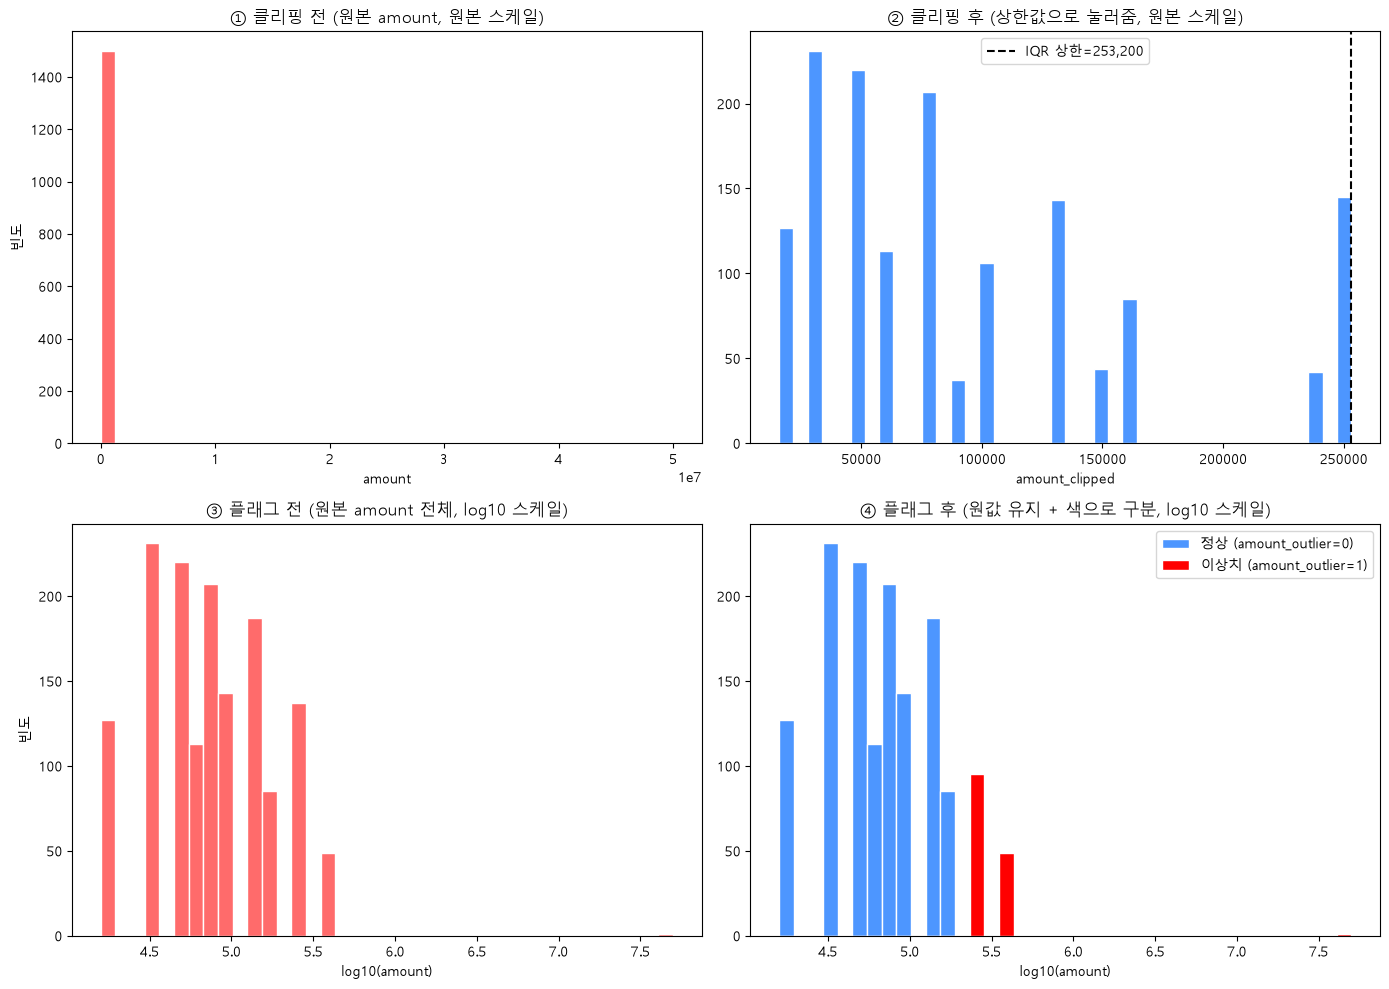

In [16]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


mask_a, (lo_a, up_a) = detect_outliers_iqr(partner_median["amount"])
partner_clipped = partner_median.copy()
partner_clipped["amount_clipped"] = partner_clipped["amount"].clip(upper=up_a)

normal_amt = partner_median.loc[partner_median["amount_outlier"] == 0, "amount"]
outlier_amt = partner_median.loc[partner_median["amount_outlier"] == 1, "amount"]

log_all = np.log10(partner_median["amount"])
shared_bins_log = np.linspace(log_all.min(), log_all.max(), 40)
shared_bins_raw = np.linspace(0, partner_median["amount"].max(), 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ① 클리핑 전 - 원본 스케일
axes[0, 0].hist(partner_median["amount"], bins=shared_bins_raw, color="#FF6B6B", edgecolor="white")
axes[0, 0].set_title("① 클리핑 전 (원본 amount, 원본 스케일)")
axes[0, 0].set_xlabel("amount"); axes[0, 0].set_ylabel("빈도")

# ② 클리핑 후 - 원본 스케일 (상한값에 뭉침)
axes[0, 1].hist(partner_clipped["amount_clipped"], bins=40, color="#4D96FF", edgecolor="white")
axes[0, 1].axvline(up_a, color="black", linestyle="--", label=f"IQR 상한={up_a:,.0f}")
axes[0, 1].set_title("② 클리핑 후 (상한값으로 눌러줌, 원본 스케일)")
axes[0, 1].set_xlabel("amount_clipped"); axes[0, 1].legend()

# ③ 플래그 전 - 전체 amount (log 스케일, 색 구분 없음)
axes[1, 0].hist(log_all, bins=shared_bins_log, color="#FF6B6B", edgecolor="white")
axes[1, 0].set_title("③ 플래그 전 (원본 amount 전체, log10 스케일)")
axes[1, 0].set_xlabel("log10(amount)"); axes[1, 0].set_ylabel("빈도")

# ④ 플래그 후 - 정상/이상치 색 구분 (원값 그대로, log 스케일)
axes[1, 1].hist(np.log10(normal_amt), bins=shared_bins_log, color="#4D96FF", edgecolor="white", label="정상 (amount_outlier=0)")
axes[1, 1].hist(np.log10(outlier_amt), bins=shared_bins_log, color="red", edgecolor="white", label="이상치 (amount_outlier=1)")
axes[1, 1].set_title("④ 플래그 후 (원값 유지 + 색으로 구분, log10 스케일)")
axes[1, 1].set_xlabel("log10(amount)"); axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
# 시나리오 3 — 처리 코드 (예시 구현)
#사본
partner_clean = partner.copy()

# 1) customer_age 물리적 불가능 값 → NaN → 중앙값 대체
unrealistic = (partner_clean["customer_age"] < 1) | (partner_clean["customer_age"] > 110)
partner_clean.loc[unrealistic, "customer_age"] = np.nan
partner_clean["customer_age"] = partner_clean["customer_age"].fillna(
    partner_clean["customer_age"].median()
).astype(int)

# 2) quantity 이상치 → NaN → 중앙값 대체
mask_q, _ = detect_outliers_iqr(partner_clean["quantity"])
partner_clean.loc[mask_q, "quantity"] = np.nan
partner_clean["quantity"] = partner_clean["quantity"].fillna(
    partner_clean["quantity"].median()
).astype(int)

# 3) amount 이상치(50,000,000) → 유지 + 플래그
mask_a, _ = detect_outliers_iqr(partner_clean["amount"])
partner_clean["amount_outlier"] = mask_a.astype(int)

# 4) amount 결측 → 채널별 중앙값 대체 (MAR 가설)
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 5) price 결측 → 카테고리별 중앙값 대체
partner_clean["price"] = partner_clean["price"].fillna(
    partner_clean.groupby("category")["price"].transform("median")
)

# 검증 출력
print("[처리 전 후 결측 비교]")
before = partner.isnull().sum()
after = partner_clean[partner.columns].isnull().sum()
display(pd.DataFrame({"before": before, "after": after}))

print("\n[처리 후 customer_age 범위]:",
      partner_clean["customer_age"].min(), "~", partner_clean["customer_age"].max())
print("[amount_outlier=1 건수]:", partner_clean["amount_outlier"].sum())

[처리 전 후 결측 비교]


,before,after
order_id,0,0
customer_age,0,0
category,0,0
channel,0,0
price,5,0
quantity,0,0
amount,51,0
return_amount,0,0



[처리 후 customer_age 범위]: 5 ~ 60
[amount_outlier=1 건수]: 145
